## Resultados de modelo 
En este notebook se muestran los resultados del modelo entrenado. Se hizo un entrenamiento con un Autoencoder sobre personas que no están en situación de pobreza. Ahora se cargará el modelo y se harán inferencias sobre personas "pobres".

In [6]:
from google.colab import drive
import os

# Monta Google Drive en el directorio /content/drive
drive.mount('/content/drive')

# Opcional: Verifica que se montó correctamente listando el contenido de tu Drive
# Ajusta la ruta a una carpeta que sepas que existe en tu Drive
print("\nContenido de la raíz de tu Google Drive:")
# El directorio base suele ser /content/drive/MyDrive/
drive_path = '/content/drive/MyDrive/'
if os.path.exists(drive_path):
    print(os.listdir(drive_path)[:10]) # Muestra los primeros 10 archivos/carpetas
else:
    print(f"El directorio {drive_path} no se encontró. Revisa la ruta.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Contenido de la raíz de tu Google Drive:
['Doctorado_DavidLizama', 'DataturReportePublico.csv', 'DataturReportePublico (1).gsheet', 'DataturReportePublico.gsheet', 'Tomorrowland 2025.gsheet', 'Mentoria', '¿Cómo mejorar mis técnicas de estudio__MATERIAL BECARIO.doc.gdoc', '¿Cómo ser un agente de cambio__MATERIALBECARIO.gdoc', 'volaris.gsheet', 'kiubo.gsheet']


In [7]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import joblib
import os

# --- 1. Definir las rutas a tus archivos ---
# Asegúrate de que tu Google Drive ya esté montado en /content/drive
path_model = '/content/drive/MyDrive/Doctorado_DavidLizama/datos_tesis/coneval/2024/Bases de datos/autoencoder_final.keras'
path_scaler = '/content/drive/MyDrive/Doctorado_DavidLizama/datos_tesis/coneval/2024/Bases de datos/scaler_final.joblib'

# --- 2. Cargar el modelo y el escalador ---
print("--- Iniciando la carga de artefactos ---")

autoencoder = None
scaler = None

try:
    # Verificar que los archivos existen antes de intentar cargarlos
    if not os.path.exists(path_model):
        raise FileNotFoundError(f"No se encontró el archivo del modelo en: {path_model}")
    if not os.path.exists(path_scaler):
        raise FileNotFoundError(f"No se encontró el archivo del escalador en: {path_scaler}")

    # Cargar el modelo de Keras
    # Usamos compile=False para cargar solo la arquitectura y los pesos.
    # Luego lo recompilamos manualmente para tener control total.
    print(f"Cargando modelo desde: {path_model}")
    autoencoder = load_model(path_model, compile=False)

    # Recompilar el modelo con los mismos parámetros del entrenamiento
    # Este learning rate (lr) viene de tu script de entrenamiento (train_final_model.py)
    lr_optimo = 0.000576
    print(f"Recompilando el modelo con optimizador Adam (lr={lr_optimo}) y loss='mse'...")
    autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_optimo), loss='mse')
    
    # Cargar el escalador de scikit-learn
    print(f"Cargando escalador desde: {path_scaler}")
    scaler = joblib.load(path_scaler)
    
    print("\n¡Modelo y escalador cargados y listos para usar!")
    
    # Opcional: Mostrar un resumen del modelo para verificar que se cargó bien
    print("\nResumen del modelo:")
    autoencoder.summary()

except Exception as e:
    print(f"\n--- ERROR ---")
    print(f"Ocurrió un error durante la carga: {e}")
    print("Por favor, verifica lo siguiente:")
    print("1. Que hayas montado tu Google Drive correctamente.")
    print("2. Que las rutas a los archivos '.keras' y '.joblib' sean exactas.")
    print("3. Que las versiones de TensorFlow y scikit-learn sean compatibles con las que usaste para guardar los archivos.")

# --- 3. Verificar los objetos cargados ---
if autoencoder and scaler:
    print("\nVerificación final:")
    print(f"  - Objeto del modelo: {type(autoencoder)}")
    print(f"  - Objeto del escalador: {type(scaler)}")
    # Si el scaler se ajustó a un DataFrame de pandas, puedes ver las features
    if hasattr(scaler, 'feature_names_in_'):
        print(f"  - El escalador fue ajustado con {len(scaler.feature_names_in_)} variables.")



--- Iniciando la carga de artefactos ---
Cargando modelo desde: /content/drive/MyDrive/Doctorado_DavidLizama/datos_tesis/coneval/2024/Bases de datos/autoencoder_final.keras
Recompilando el modelo con optimizador Adam (lr=0.000576) y loss='mse'...
Cargando escalador desde: /content/drive/MyDrive/Doctorado_DavidLizama/datos_tesis/coneval/2024/Bases de datos/scaler_final.joblib

¡Modelo y escalador cargados y listos para usar!

Resumen del modelo:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 216)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_0 (Dense)         │ (None, 432)            │        93,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_0 (Dropout)     │ (None, 432)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_1 (Dense)         │ (None, 387)            │       167,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_1 (Dropout)     │ (None, 387)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_2 (Dense)         │ (None, 362)            │       140,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_2 (Dropout)     │ (None, 362)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 15)             │         5,445 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 362)            │         5,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_2 (Dropout)     │ (None, 362)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 387)            │       140,481 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_1 (Dropout)     │ (None, 387)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_0 (Dense)         │ (None, 432)            │       167,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_0 (Dropout)     │ (None, 432)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 216)            │        93,528 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 814,633 (3.11 MB)

 Trainable params: 814,633 (3.11 MB)

 Non-trainable params: 0 (0.00 B)


Verificación final:
  - Objeto del modelo: <class 'keras.src.models.functional.Functional'>
  - Objeto del escalador: <class 'sklearn.preprocessing._data.MinMaxScaler'>
  - El escalador fue ajustado con 216 variables.


In [8]:
import pandas as pd
import numpy as np
import os

# --- 1. Definir rutas y cargar los datos ---
# Asegúrate de que tu Google Drive ya esté montado.
BASE_DIR = "/content/drive/MyDrive/Doctorado_DavidLizama/datos_tesis/coneval/2024/Bases de datos/"
path_pobres = os.path.join(BASE_DIR, "pobres.csv")
path_no_pobres = os.path.join(BASE_DIR, "no_pobres.csv")

print("--- Cargando datasets para el análisis ---")
df_pobres = None
df_no_pobres = None

try:
    # Cargar el dataset de hogares en pobreza
    if not os.path.exists(path_pobres):
        raise FileNotFoundError(f"No se encontró el archivo 'pobres.csv' en: {path_pobres}")
    df_pobres = pd.read_csv(path_pobres)
    print(f"Datos de 'pobres' cargados: {df_pobres.shape}")

    # Cargar el dataset de hogares no pobres (útil para el background de SHAP)
    if not os.path.exists(path_no_pobres):
        raise FileNotFoundError(f"No se encontró el archivo 'no_pobres.csv' en: {path_no_pobres}")
    df_no_pobres = pd.read_csv(path_no_pobres)
    print(f"Datos de 'no pobres' cargados: {df_no_pobres.shape}")

except Exception as e:
    print(f"\n--- ERROR ---")
    print(f"Ocurrió un error al cargar los datos: {e}")
    print("Verifica que las rutas y los nombres de archivo sean correctos.")

# --- 2. Función de preprocesamiento para inferencia ---
# Esta función es clave para asegurar que los datos nuevos se procesan
# exactamente igual que los datos de entrenamiento.

def preprocess_data_for_inference(df, scaler):
    """
    Prepara un DataFrame para la inferencia con el autoencoder.
    - Extrae el factor de expansión.
    - Selecciona las columnas correctas usando la info del scaler.
    - Aplica la transformación del escalador (sin volver a ajustarlo).
    """
    # Usar las features con las que se entrenó el scaler para garantizar consistencia
    feature_cols = scaler.feature_names_in_
    
    # Asegurarse de que el DataFrame de entrada tiene todas las columnas necesarias
    missing_cols = [col for col in feature_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Faltan las siguientes columnas en el DataFrame: {missing_cols}")
    
    # Extraer el factor de expansión para análisis ponderado posterior
    factor = df['factor'].copy()
    
    # Seleccionar solo las features en el orden correcto
    df_features = df[feature_cols]
    
    # Aplicar la transformación del scaler (NO se usa fit_transform)
    X_scaled = scaler.transform(df_features)
    
    return X_scaled, factor, feature_cols

# --- 3. Procesar los DataFrames ---
# (Asegúrate de haber ejecutado la celda anterior donde cargaste el 'scaler')

if df_pobres is not None and df_no_pobres is not None:
    print("\n--- Preprocesando datos para el análisis ---")
    try:
        # Verificar que el objeto 'scaler' existe
        if 'scaler' not in locals():
            raise NameError("El objeto 'scaler' no está definido. Asegúrate de haberlo cargado primero.")

        # Procesar el dataset de POBRES
        X_pobres_scaled, factor_pobres, feature_names = preprocess_data_for_inference(df_pobres, scaler)
        
        # Procesar el dataset de NO POBRES
        X_no_pobres_scaled, factor_no_pobres, _ = preprocess_data_for_inference(df_no_pobres, scaler)

        print("Datos procesados y escalados correctamente.")
        print(f"  - Shape de datos 'pobres' escalados: {X_pobres_scaled.shape}")
        print(f"  - Shape de datos 'no pobres' escalados: {X_no_pobres_scaled.shape}")
        print(f"  - Número de features utilizadas: {len(feature_names)}")

    except (NameError, ValueError) as e:
        print(f"\n--- ERROR ---")
        print(f"Ocurrió un error durante el preprocesamiento: {e}")



--- Cargando datasets para el análisis ---
Datos de 'pobres' cargados: (90017, 222)
Datos de 'no pobres' cargados: (218427, 222)

--- Preprocesando datos para el análisis ---
Datos procesados y escalados correctamente.
  - Shape de datos 'pobres' escalados: (90017, 216)
  - Shape de datos 'no pobres' escalados: (218427, 216)
  - Número de features utilizadas: 216


### Paso 1: Cálculo del error de reconstrucción


Generando reconstrucciones con el autoencoder...
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 4s 847us/step

Cálculo del error de reconstrucción completado.
Resumen estadístico del error:
count    90017.000000
mean         0.007118
std          0.008260
min          0.000046
25%          0.000713
50%          0.004929
75%          0.010714
max          0.290103
Name: reconstruction_error, dtype: float64


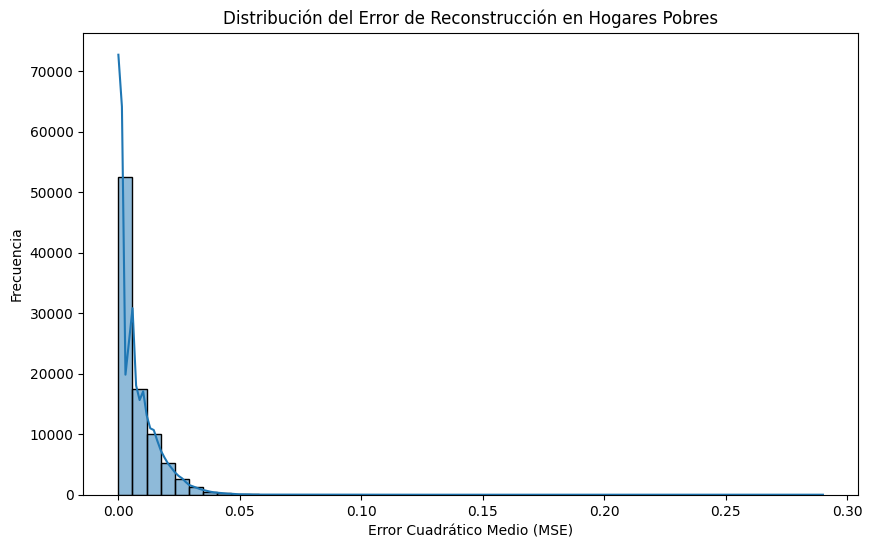

In [9]:
# Paso 1: Cálculo del error de reconstrucción
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Predecir (reconstruir) los datos de los pobres ---
# (Asegúrate de tener 'autoencoder' y 'X_pobres_scaled' de los pasos anteriores)
print("Generando reconstrucciones con el autoencoder...")
reconstructions = autoencoder.predict(X_pobres_scaled)

# --- 2. Calcular el Error Cuadrático Medio (MSE) por observación ---
# Este será nuestro indicador de "anomalía" para cada hogar.
mse_per_observation = np.mean((X_pobres_scaled - reconstructions)**2, axis=1)

# --- 3. Añadir el error al DataFrame original para análisis ---
# (Asegúrate de tener 'df_pobres' cargado)
df_pobres['reconstruction_error'] = mse_per_observation

print("\nCálculo del error de reconstrucción completado.")
print("Resumen estadístico del error:")
print(df_pobres['reconstruction_error'].describe())

# --- 4. Visualizar la distribución del error (Opcional pero recomendado) ---
plt.figure(figsize=(10, 6))
sns.histplot(df_pobres['reconstruction_error'], bins=50, kde=True)
plt.title('Distribución del Error de Reconstrucción en Hogares Pobres')
plt.xlabel('Error Cuadrático Medio (MSE)')
plt.ylabel('Frecuencia')
plt.show()


### Interpretar error SHAP

In [ ]:
### Interpretar error SHAP
import shap

# --- 1. Crear un "background dataset" ---
# SHAP necesita una referencia para calcular las contribuciones. Usamos una muestra
# de los datos "normales" (no pobres) con los que se entrenó el modelo.
# (Asegúrate de tener 'X_no_pobres_scaled' del paso de preprocesamiento)
print("Creando muestra de background para SHAP con 100 registros de 'no pobres'...")
background_sample = shap.sample(X_no_pobres_scaled, 100)

# --- 2. Inicializar el explainer de SHAP ---
# GradientExplainer es eficiente para modelos de TensorFlow/Keras.
# Si tienes una GPU en Colab, TensorFlow la usará automáticamente, acelerando el proceso.
print("Inicializando GradientExplainer de SHAP...")
explainer = shap.GradientExplainer(autoencoder, background_sample)

# --- 3. Calcular los valores SHAP para el dataset de pobres ---
# ¡Esta es la parte más intensiva! Puede tardar varios minutos.
print("Calculando valores SHAP para el dataset de 'pobres'. Esto puede tardar...")
shap_values = explainer.shap_values(X_pobres_scaled)

# El resultado es una lista de arrays. Para un modelo con una sola salida,
# nos quedamos con el primer elemento.
shap_values_pobres = shap_values[0]

print("\n¡Cálculo de SHAP finalizado!")
print(f"Shape de los valores SHAP: {shap_values_pobres.shape}")


Creando muestra de background para SHAP con 100 registros de 'no pobres'...
Inicializando GradientExplainer de SHAP...
Calculando valores SHAP para el dataset de 'pobres'. Esto puede tardar...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(90017, 216))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(50, 216))']
  warnings.warn(msg)


### Análisis visual SHAP

In [ ]:
# --- 1. Identificar los hogares con mayor error de reconstrucción ---
# Analizaremos los 200 hogares más anómalos.
top_error_indices = df_pobres['reconstruction_error'].nlargest(200).index

# --- 2. Crear un objeto de explicación de SHAP para graficar ---
# (Asegúrate de tener 'feature_names' del paso de preprocesamiento)
shap_explanation = shap.Explanation(
    values=shap_values_pobres[top_error_indices],
    base_values=explainer.expected_value[0],
    data=X_pobres_scaled[top_error_indices],
    feature_names=feature_names
)

# --- 3. Generar el SHAP Summary Plot ---
print("\nGenerando SHAP Summary Plot para los 200 hogares con mayor error...")
plt.figure()
shap.summary_plot(shap_explanation, max_display=20, show=True)


### Cálculo de la importancia Global Ponderada

In [ ]:
# --- 1. Ponderar los valores SHAP absolutos por el factor de expansión ---
# (Asegúrate de tener 'factor_pobres' del paso de preprocesamiento)
print("Calculando la importancia global ponderada de las variables...")
abs_shap_values = np.abs(shap_values_pobres)
weighted_shap_values = abs_shap_values * factor_pobres.to_numpy()[:, np.newaxis]

# --- 2. Calcular el impacto global y normalizar ---
# Sumamos el impacto ponderado por cada variable y lo dividimos por la suma total
# de los factores para obtener un promedio comparable.
global_weighted_impact = pd.Series(np.sum(weighted_shap_values, axis=0), index=feature_names)
total_factor_sum = factor_pobres.sum()
mean_global_weighted_impact = global_weighted_impact / total_factor_sum

# Ordenar de mayor a menor impacto
mean_global_weighted_impact.sort_values(ascending=False, inplace=True)

print("\nTop 10 variables con mayor impacto global ponderado:")
print(mean_global_weighted_impact.head(10))


### Visualización de dimensiones de pobreza

In [ ]:
# --- Gráfico 1: Top 20 de todas las variables ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 10))
mean_global_weighted_impact.head(20).sort_values(ascending=True).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Variables con Mayor Impacto Global Ponderado', fontsize=16)
ax.set_xlabel('Impacto SHAP Absoluto Promedio Ponderado', fontsize=12)
ax.set_ylabel('Variables', fontsize=12)
plt.tight_layout()
plt.show()

# --- Filtro para excluir variables tradicionales ---
# Usamos la lista de keywords de tu script 'run_poverty_analysis.py', que es muy completa.
def filter_coneval_vars(impact_series):
    """Filtra variables del índice de pobreza de CONEVAL."""
    coneval_keywords = [
        'ing_', 'gasto_', 'carencia', 'rezago_educ', 'acceso_salud', 
        'seguridad_social', 'alim', 'serv_agua', 'serv_dren', 'serv_luz',
        'pared', 'techo', 'piso', 'combustible'
    ]
    mask = ~impact_series.index.str.contains('|'.join(coneval_keywords), case=False)
    return impact_series[mask]

print("\nFiltrando variables tradicionales para encontrar 'nuevas dimensiones'...")
non_coneval_impact = filter_coneval_vars(mean_global_weighted_impact)
top_15_new_dimensions = non_coneval_impact.head(15)

print("\nTop 15 'Nuevas Dimensiones' de Pobreza encontradas:")
print(top_15_new_dimensions)

# --- Gráfico 2: Top 15 de "Nuevas Dimensiones" ---
fig, ax = plt.subplots(figsize=(12, 10))
top_15_new_dimensions.sort_values(ascending=True).plot(kind='barh', ax=ax, color='skyblue')
ax.set_title('Top 15 Nuevas Dimensiones de Pobreza (Impacto Global Ponderado)', fontsize=16)
ax.set_xlabel('Impacto SHAP Absoluto Promedio Ponderado', fontsize=12)
ax.set_ylabel('Variables', fontsize=12)
plt.tight_layout()
plt.show()
